# 5G QoS Predictor — Synthetic Data Generator Visualization

This notebook visualizes the output of the synthetic 5G slice data generator:
intraday load profiles, KPI time-series with event annotations, label distributions,
and cross-slice PRB coupling.

## 0. Imports & Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 4)})

## 1. Generate All Slices

Call `generate_all_slices()` and display row counts and schema (dtypes) for each slice.

In [2]:
from src.data.generator import generate_all_slices

slices = generate_all_slices(days=90)

for slice_type, df in slices.items():
    print(f"\n{'='*50}")
    print(f"Slice: {slice_type}  |  Rows: {len(df):,}")
    print(f"{'='*50}")
    display(df.dtypes.rename("dtype").to_frame())


Slice: eMBB  |  Rows: 25,920


,dtype
timestamp,datetime64[us]
slice_type,str
event_type,str
dl_throughput,float64
latency,float64
jitter,float64
packet_loss,float64
prb_util,float64
active_users,float64
reliability,float64



Slice: URLLC  |  Rows: 25,920


,dtype
timestamp,datetime64[us]
slice_type,str
event_type,str
dl_throughput,float64
latency,float64
jitter,float64
packet_loss,float64
prb_util,float64
active_users,float64
reliability,float64



Slice: mMTC  |  Rows: 25,920


,dtype
timestamp,datetime64[us]
slice_type,str
event_type,str
dl_throughput,float64
latency,float64
jitter,float64
packet_loss,float64
prb_util,float64
active_users,float64
reliability,float64


## 2. Intraday Load Profiles

Reconstruct the intraday load for a single representative day (288 timesteps) for each slice type.
- **eMBB**: triple-hump Gaussian (morning commute, lunch, evening streaming)
- **URLLC**: sigmoid business-hours plateau
- **mMTC**: periodic impulse bursts

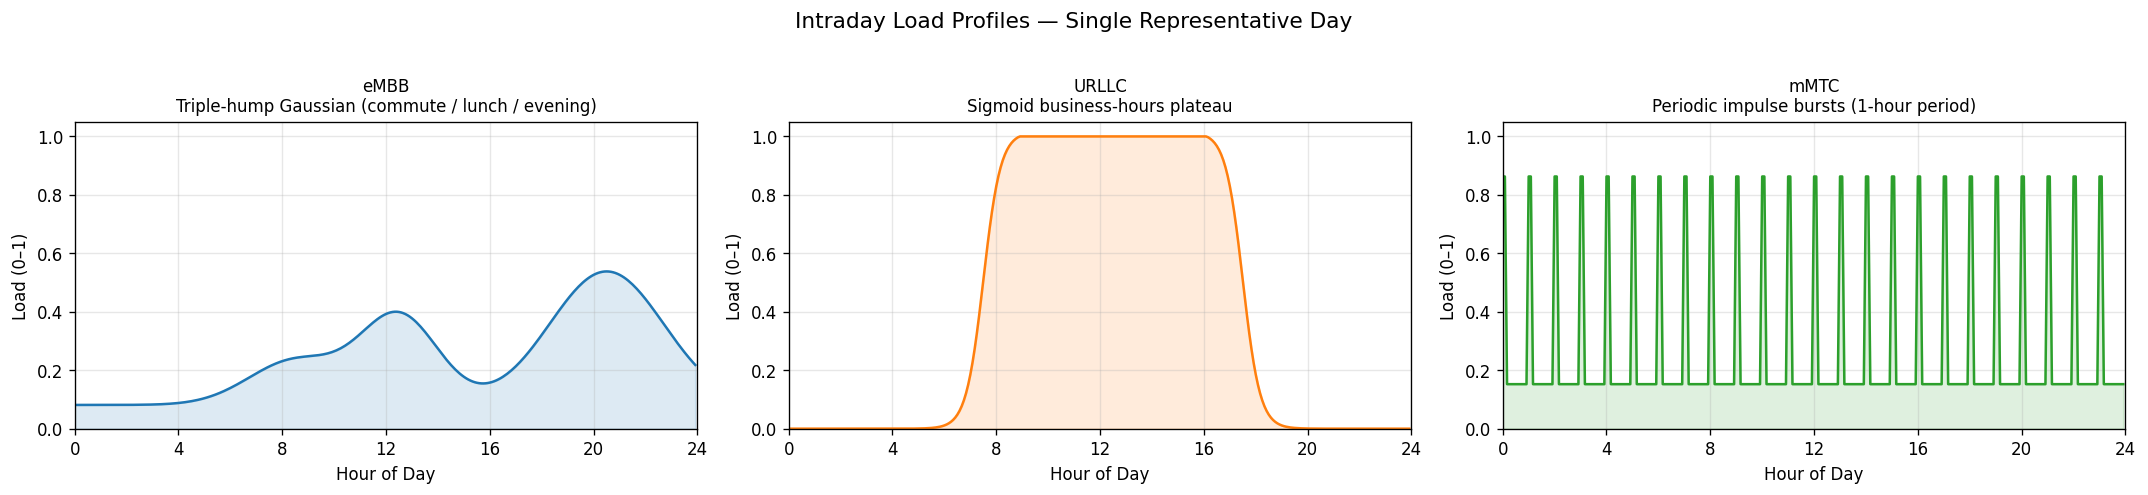

In [3]:
from src.data.generator import build_load_profile

rng = np.random.default_rng(42)
load_embb, _, ts_embb = build_load_profile("eMBB", 288, rng)

rng = np.random.default_rng(42)
load_urllc, _, ts_urllc = build_load_profile("URLLC", 288, rng)

rng = np.random.default_rng(42)
load_mmtc, _, ts_mmtc = build_load_profile("mMTC", 288, rng)

# Convert timestamps to hour-of-day float
hours = ts_embb.hour + ts_embb.minute / 60.0

slice_profiles = [
    ("eMBB",  load_embb,  "Triple-hump Gaussian (commute / lunch / evening)", "#1f77b4"),
    ("URLLC", load_urllc, "Sigmoid business-hours plateau",                   "#ff7f0e"),
    ("mMTC",  load_mmtc,  "Periodic impulse bursts (1-hour period)",          "#2ca02c"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (name, load, desc, color) in zip(axes, slice_profiles):
    ax.plot(hours, load, color=color, linewidth=1.5)
    ax.fill_between(hours, load, alpha=0.15, color=color)
    ax.set_title(f"{name}\n{desc}", fontsize=10)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Load (0–1)")
    ax.set_xlim(0, 24)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(0, 25, 4))
    ax.grid(True, alpha=0.3)

fig.suptitle("Intraday Load Profiles — Single Representative Day", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 3. KPI Time-Series (7-day window) with Event Annotations

For each slice, plot 3 key KPIs over the first 7 days. Event regions (non-normal) are shaded.

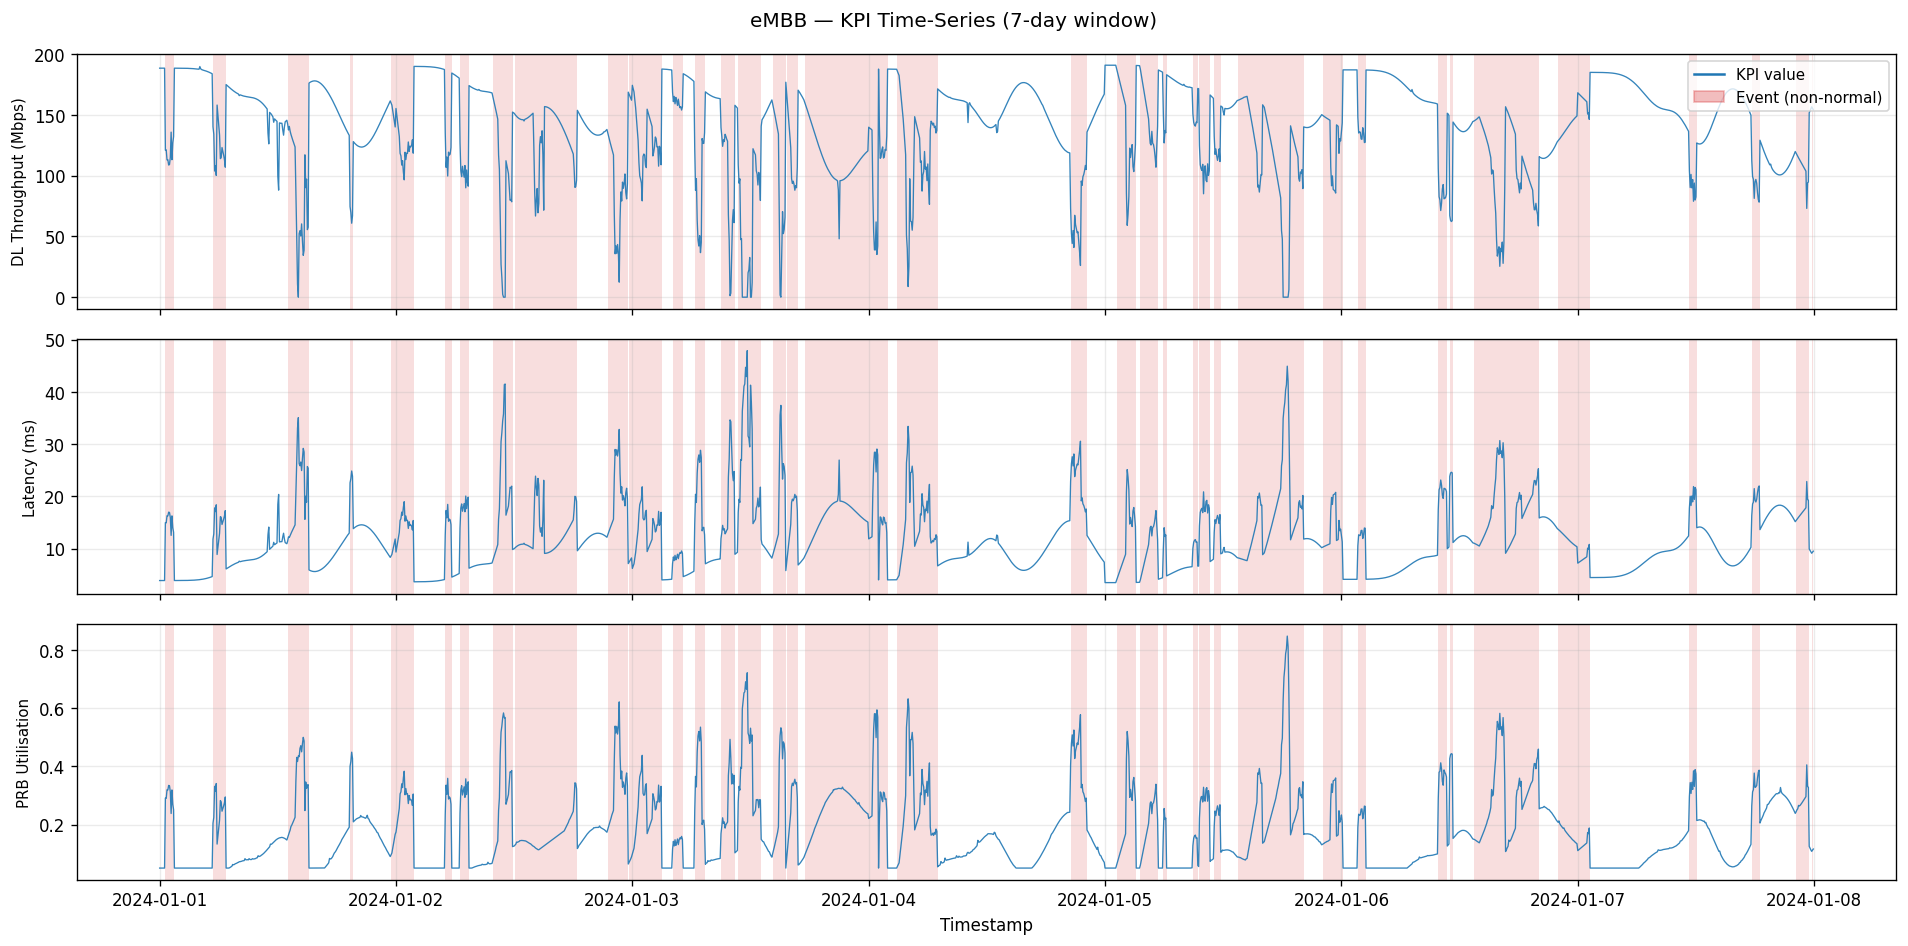

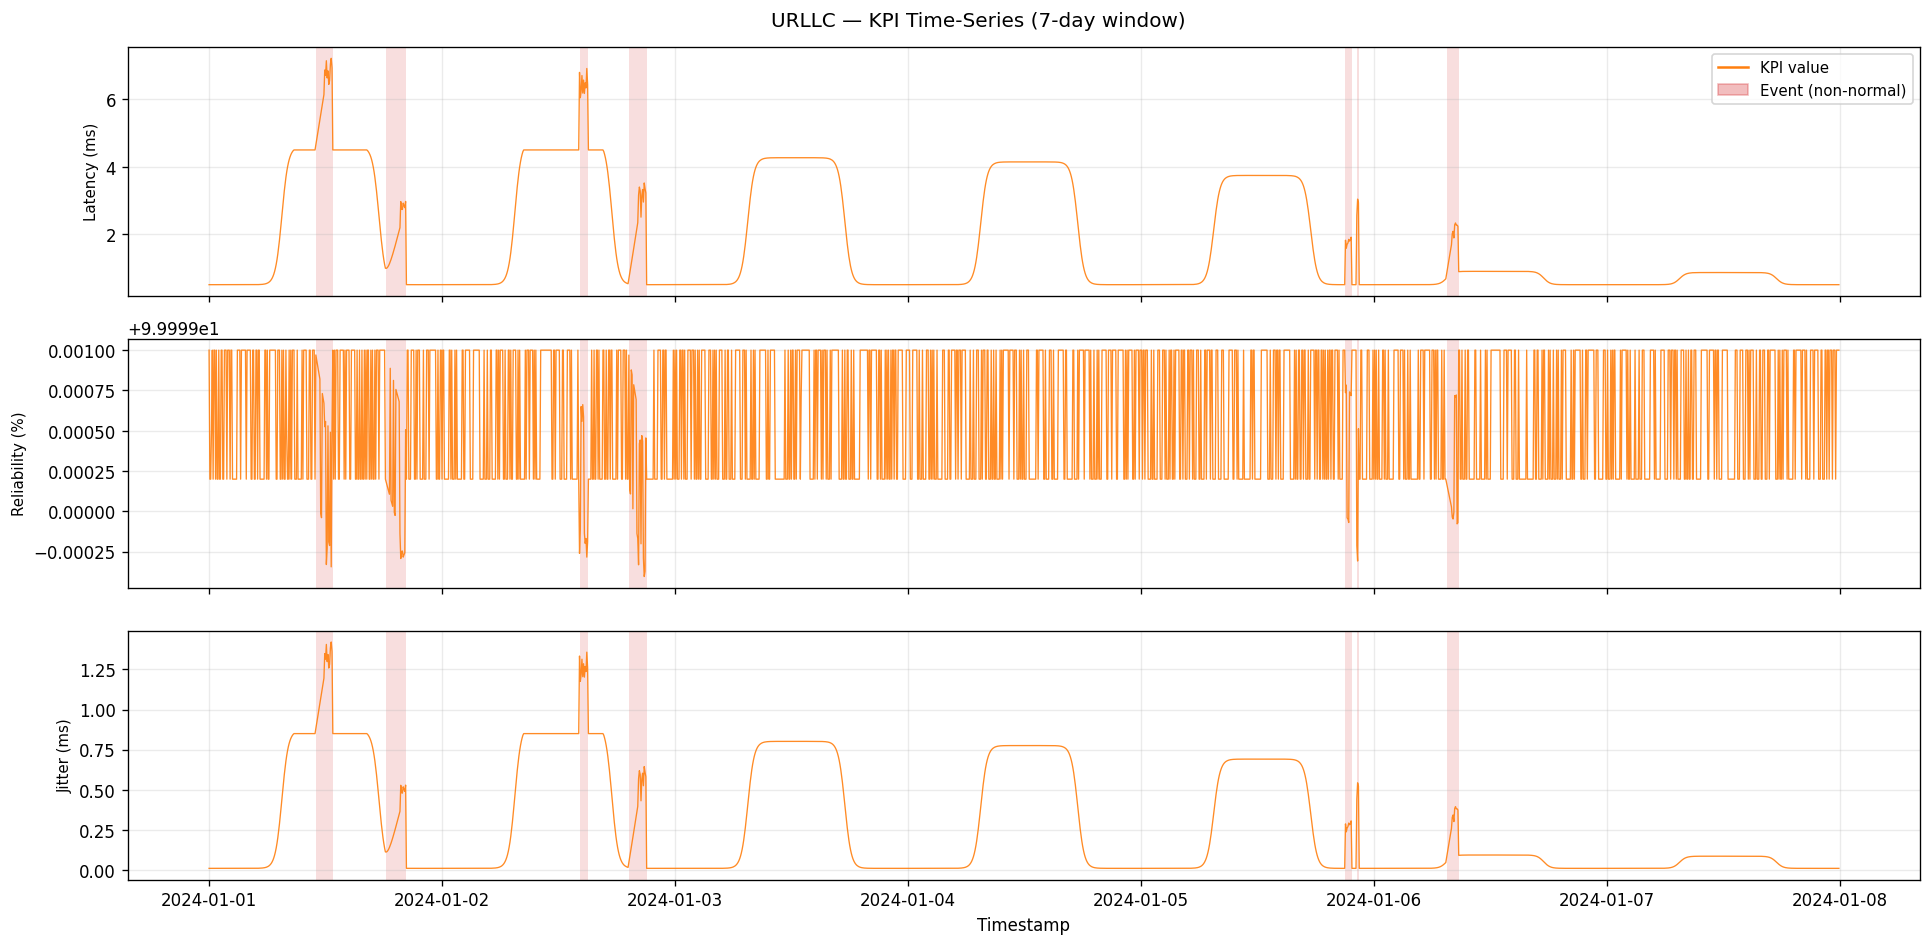

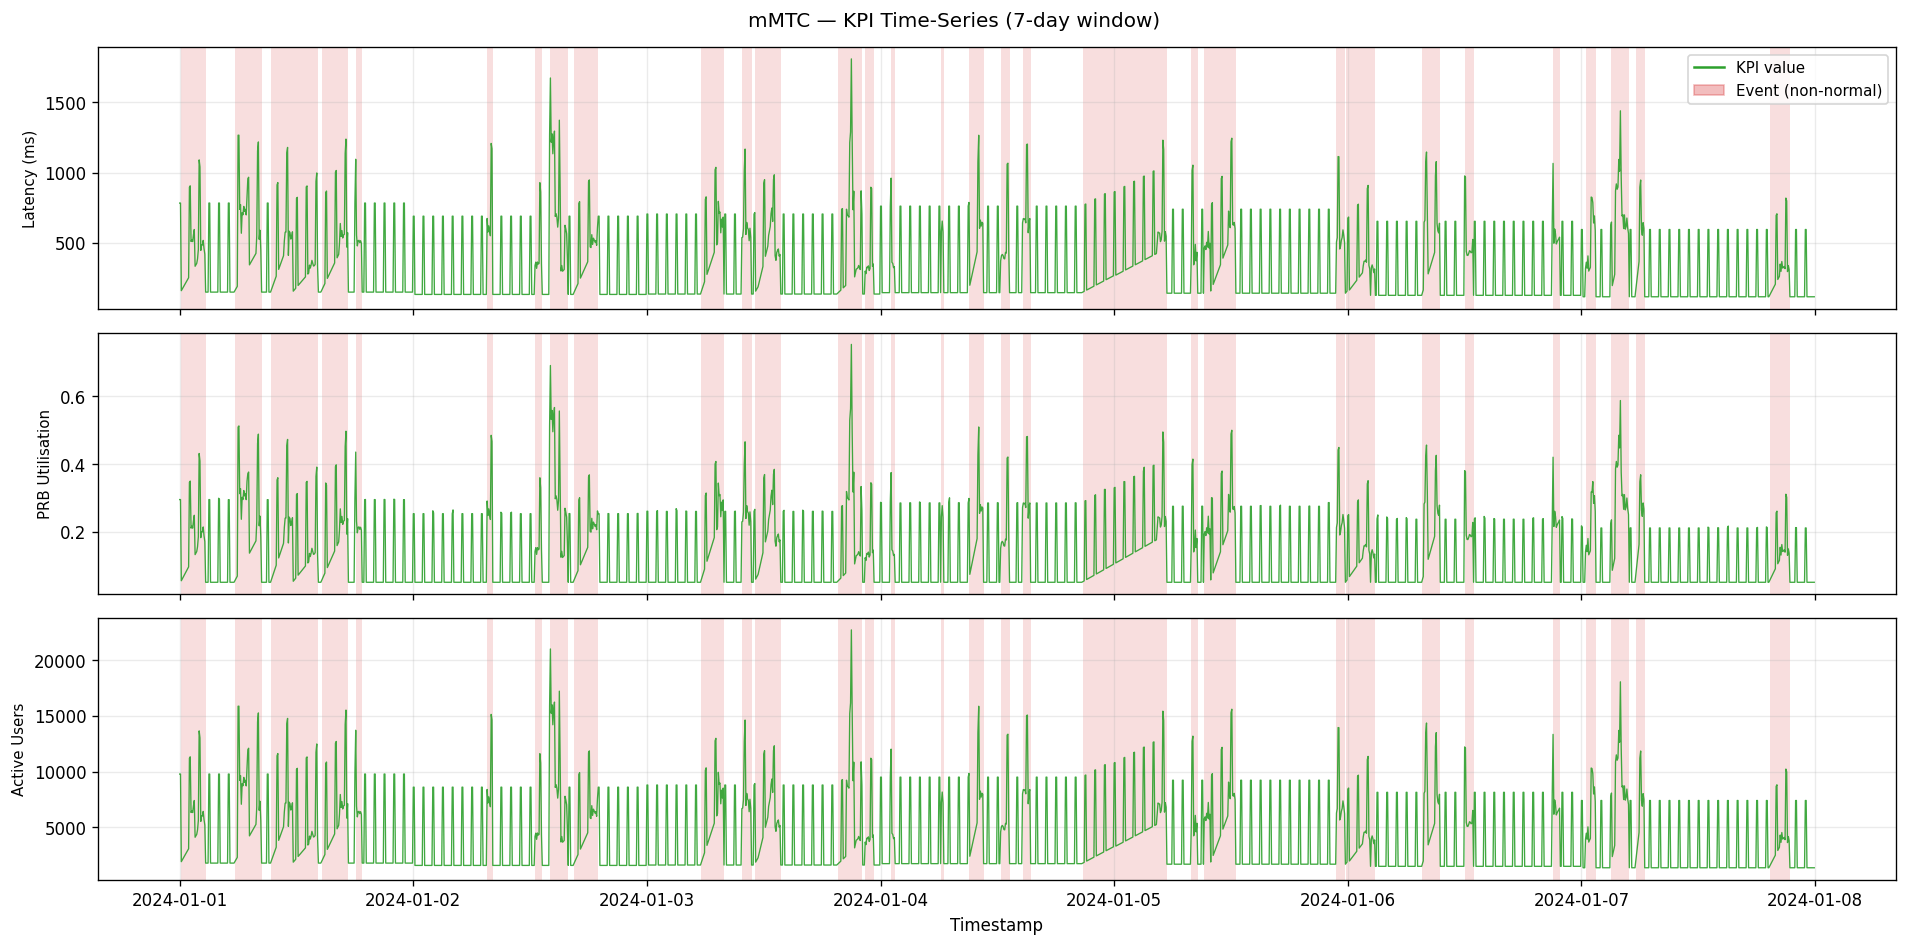

In [4]:
INTERVALS_PER_DAY = 288
WINDOW = 7 * INTERVALS_PER_DAY  # first 7 days

# KPIs to plot per slice
SLICE_KPIS = {
    "eMBB":  [("dl_throughput", "DL Throughput (Mbps)"),
              ("latency",       "Latency (ms)"),
              ("prb_util",      "PRB Utilisation")],
    "URLLC": [("latency",       "Latency (ms)"),
              ("reliability",   "Reliability (%)"),
              ("jitter",        "Jitter (ms)")],
    "mMTC":  [("latency",       "Latency (ms)"),
              ("prb_util",      "PRB Utilisation"),
              ("active_users",  "Active Users")],
}

SLICE_COLORS = {"eMBB": "#1f77b4", "URLLC": "#ff7f0e", "mMTC": "#2ca02c"}
EVENT_COLOR  = "#d62728"

for slice_type, kpi_list in SLICE_KPIS.items():
    df_w = slices[slice_type].iloc[:WINDOW].copy()
    ts   = df_w["timestamp"]
    color = SLICE_COLORS[slice_type]

    fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

    for ax, (kpi, ylabel) in zip(axes, kpi_list):
        ax.plot(ts, df_w[kpi], color=color, linewidth=0.8, alpha=0.9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(True, alpha=0.25)

        # Shade event regions
        in_event = False
        event_start = None
        for i, (t, etype) in enumerate(zip(ts, df_w["event_type"])):
            if etype != "normal" and not in_event:
                in_event = True
                event_start = t
            elif etype == "normal" and in_event:
                ax.axvspan(event_start, t, alpha=0.15, color=EVENT_COLOR, linewidth=0)
                in_event = False
        if in_event:
            ax.axvspan(event_start, ts.iloc[-1], alpha=0.15, color=EVENT_COLOR, linewidth=0)

    axes[-1].set_xlabel("Timestamp")

    # Legend
    legend_handles = [
        Line2D([0], [0], color=color, linewidth=1.5, label="KPI value"),
        mpatches.Patch(color=EVENT_COLOR, alpha=0.3, label="Event (non-normal)"),
    ]
    axes[0].legend(handles=legend_handles, fontsize=9, loc="upper right")

    fig.suptitle(f"{slice_type} — KPI Time-Series (7-day window)", fontsize=12)
    fig.tight_layout()
    plt.show()

## 4. Label Distributions

Positive rates for `any_breach` and the three horizon labels per slice.
Dashed lines mark the expected 2%–10% range.

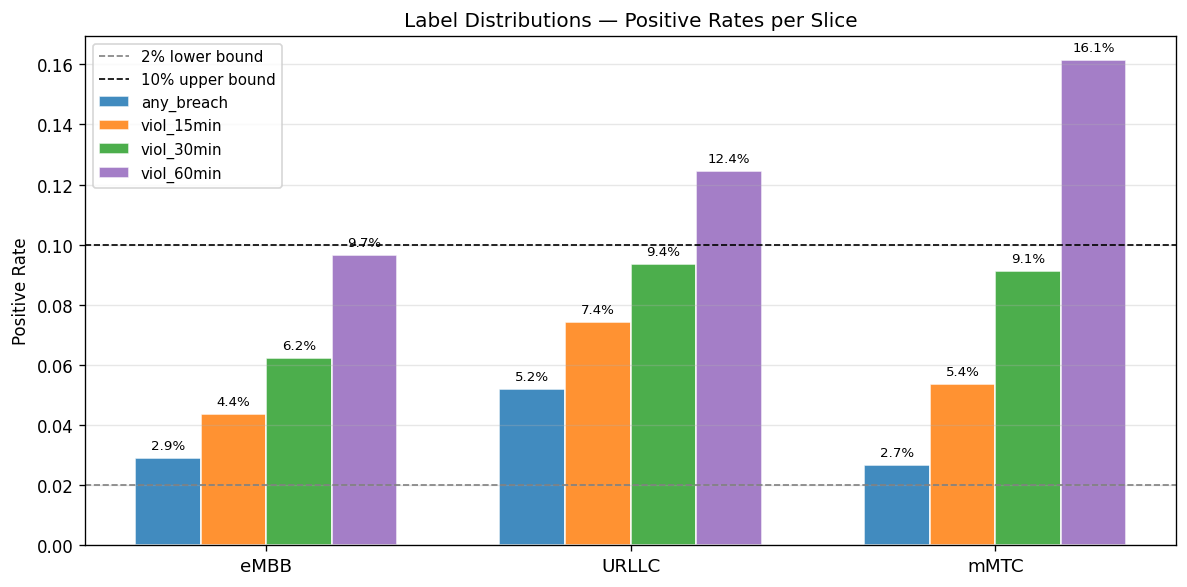

In [5]:
label_cols = ["any_breach", "violation_in_15min", "violation_in_30min", "violation_in_60min"]
label_names = ["any_breach", "viol_15min", "viol_30min", "viol_60min"]

slice_names = list(slices.keys())
rates = {lbl: [slices[s][col].mean() for s in slice_names]
         for lbl, col in zip(label_names, label_cols)}

x = np.arange(len(slice_names))
n_labels = len(label_names)
bar_width = 0.18
offsets = np.linspace(-(n_labels - 1) / 2, (n_labels - 1) / 2, n_labels) * bar_width

bar_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]

fig, ax = plt.subplots(figsize=(10, 5))

for i, (lbl, color, offset) in enumerate(zip(label_names, bar_colors, offsets)):
    bars = ax.bar(x + offset, rates[lbl], width=bar_width, label=lbl,
                  color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, rates[lbl]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f"{val:.1%}", ha="center", va="bottom", fontsize=8)

ax.axhline(0.02, color="gray", linestyle="--", linewidth=1.0, label="2% lower bound")
ax.axhline(0.10, color="black", linestyle="--", linewidth=1.0, label="10% upper bound")

ax.set_xticks(x)
ax.set_xticklabels(slice_names, fontsize=11)
ax.set_ylabel("Positive Rate")
ax.set_title("Label Distributions — Positive Rates per Slice", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Cross-Slice PRB Coupling

Stacked area chart of each slice's PRB contribution over the first 7 days.
The red dashed line marks the 90% total PRB threshold that triggers the coupling penalty.

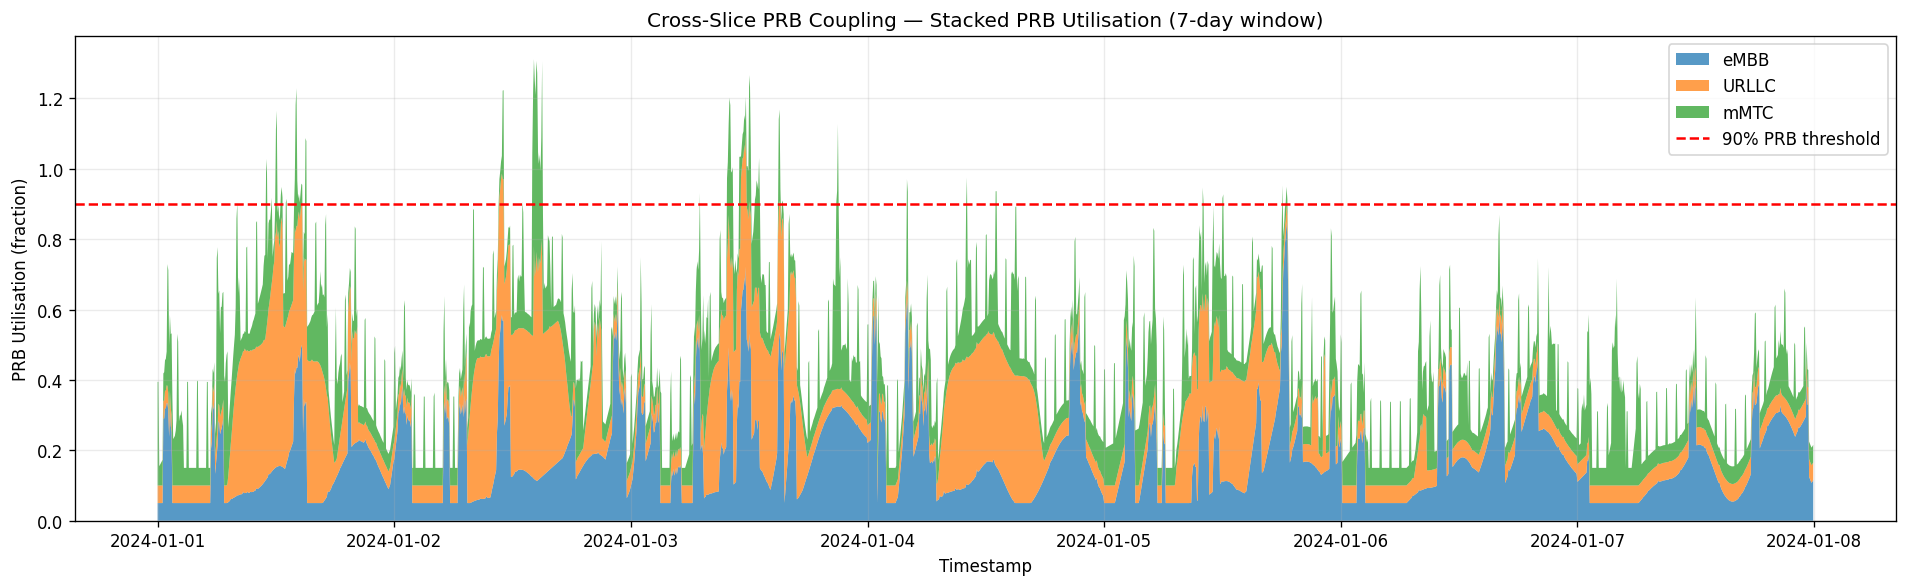

In [6]:
embb_prb  = slices["eMBB"].iloc[:WINDOW]["prb_util"].to_numpy()
urllc_prb = slices["URLLC"].iloc[:WINDOW]["prb_util"].to_numpy()
mmtc_prb  = slices["mMTC"].iloc[:WINDOW]["prb_util"].to_numpy()
ts_prb    = slices["eMBB"].iloc[:WINDOW]["timestamp"]

fig, ax = plt.subplots(figsize=(16, 5))

ax.stackplot(
    ts_prb,
    embb_prb, urllc_prb, mmtc_prb,
    labels=["eMBB", "URLLC", "mMTC"],
    colors=["#1f77b4", "#ff7f0e", "#2ca02c"],
    alpha=0.75,
)

ax.axhline(0.90, color="red", linestyle="--", linewidth=1.5, label="90% PRB threshold")

ax.set_ylabel("PRB Utilisation (fraction)")
ax.set_xlabel("Timestamp")
ax.set_title("Cross-Slice PRB Coupling — Stacked PRB Utilisation (7-day window)", fontsize=12)
ax.set_ylim(0, None)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()